In [2]:
# Import libraries using pip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project By Mohd Gulam Sheikh

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.utils.class_weight import compute_sample_weight

# Keywords using DATA GENERATION 
np.random.seed(42)
n_samples = 1470
departments = ['Sales', 'Research & Development', 'Human Resources']
job_roles = ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Manager']
business_travel = ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
marital_status = ['Single', 'Married', 'Divorced']

data = {
    'EmployeeNumber': range(1, n_samples + 1),
    'Over18': ['Y'] * n_samples,
    'StandardHours': [80] * n_samples,
    'Age': np.random.randint(18, 60, n_samples),
    'Department': np.random.choice(departments, n_samples, p=[0.3, 0.6, 0.1]),
    'JobRole': np.random.choice(job_roles, n_samples),
    'BusinessTravel': np.random.choice(business_travel, n_samples),
    'MaritalStatus': np.random.choice(marital_status, n_samples),
    'MonthlyIncome': np.random.randint(2000, 20000, n_samples),
    'WorkLifeBalance': np.random.randint(1, 5, n_samples),
    'YearsAtCompany': np.random.randint(0, 20, n_samples),
    'JobSatisfaction': np.random.randint(1, 5, n_samples),
    'PerformanceRating': np.random.choice([3, 4], n_samples, p=[0.8, 0.2]),
    'Attrition': np.random.choice(['Yes', 'No'], n_samples, p=[0.16, 0.84])
}
df = pd.DataFrame(data)
df.to_csv('HR_Attrition_Data.csv', index=False)

#  To Load CSV file
df = pd.read_csv('HR_Attrition_Data.csv')

# To use 10 rows onlly
print("--- First 10 Rows ---")
display(df.head(10))

# Cross Cheque Shape
rows, cols = df.shape
print(f"\nDataset Dimensions: {rows} rows, {cols} columns")
print(f"Target Column: Attrition (Yes/No)")

# Check Attrition Rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / rows) * 100
print(f"\nAttrition Counts:\n{attrition_counts}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

# Numeric vs Categorical analysis of data from csv
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric Columns ({len(num_cols)}): {num_cols}")
print(f"Categorical Columns ({len(cat_cols)}): {cat_cols}")

print("\n> Task 1 Observation: The dataset is heavily imbalanced. "
      f"Roughly {attrition_rate:.1f}% of employees have left ('Yes'), while the vast majority "
      f"({100-attrition_rate:.1f}%) stayed ('No'). Standard ML metrics like Accuracy will be misleading; "
      "we must track F1-Score and ROC-AUC.")

# Removing Null data
print("\nMissing values per column:\n", df.isnull().sum())

# Remove Null Value columns
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop)

# Convert Target column 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})


categorical_features = ['Department', 'JobRole', 'BusinessTravel', 'MaritalStatus']
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

# Defining features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']


numeric_features_to_scale = ['Age', 'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany', 'JobSatisfaction', 'PerformanceRating']
scaler = StandardScaler()
X[numeric_features_to_scale] = scaler.fit_transform(X[numeric_features_to_scale])

print("\nPreprocessing complete. Final feature matrix shape:", X.shape)

--- First 10 Rows ---


,EmployeeNumber,Over18,StandardHours,Age,Department,JobRole,BusinessTravel,MaritalStatus,MonthlyIncome,WorkLifeBalance,YearsAtCompany,JobSatisfaction,PerformanceRating,Attrition
0,1,Y,80,56,Research & Development,Manufacturing Director,Travel_Frequently,Divorced,3582,4,0,2,3,No
1,2,Y,80,46,Research & Development,Sales Executive,Travel_Rarely,Married,16374,1,9,3,3,No
2,3,Y,80,32,Research & Development,Manager,Travel_Rarely,Married,3308,2,13,2,4,No
3,4,Y,80,25,Research & Development,Manufacturing Director,Travel_Rarely,Married,10793,4,17,4,3,No
4,5,Y,80,38,Research & Development,Laboratory Technician,Non-Travel,Single,3620,1,5,3,3,Yes
5,6,Y,80,56,Sales,Sales Executive,Travel_Frequently,Married,6766,2,17,3,3,No
6,7,Y,80,36,Sales,Sales Executive,Travel_Rarely,Single,7192,3,19,3,3,No
7,8,Y,80,40,Sales,Laboratory Technician,Non-Travel,Married,8622,3,15,1,3,No
8,9,Y,80,28,Research & Development,Laboratory Technician,Travel_Frequently,Divorced,8093,1,14,3,3,No
9,10,Y,80,28,Sales,Sales Executive,Non-Travel,Single,18484,1,15,2,3,No



Dataset Dimensions: 1470 rows, 14 columns
Target Column: Attrition (Yes/No)

Attrition Counts:
Attrition
No     1238
Yes     232
Name: count, dtype: int64
Overall Attrition Rate: 15.78%

Numeric Columns (8): ['EmployeeNumber', 'StandardHours', 'Age', 'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany', 'JobSatisfaction', 'PerformanceRating']
Categorical Columns (6): ['Over18', 'Department', 'JobRole', 'BusinessTravel', 'MaritalStatus', 'Attrition']

> Task 1 Observation: The dataset is heavily imbalanced. Roughly 15.8% of employees have left ('Yes'), while the vast majority (84.2%) stayed ('No'). Standard ML metrics like Accuracy will be misleading; we must track F1-Score and ROC-AUC.

Missing values per column:
 EmployeeNumber       0
Over18               0
StandardHours        0
Age                  0
Department           0
JobRole              0
BusinessTravel       0
MaritalStatus        0
MonthlyIncome        0
WorkLifeBalance      0
YearsAtCompany       0
JobSatisfaction      0

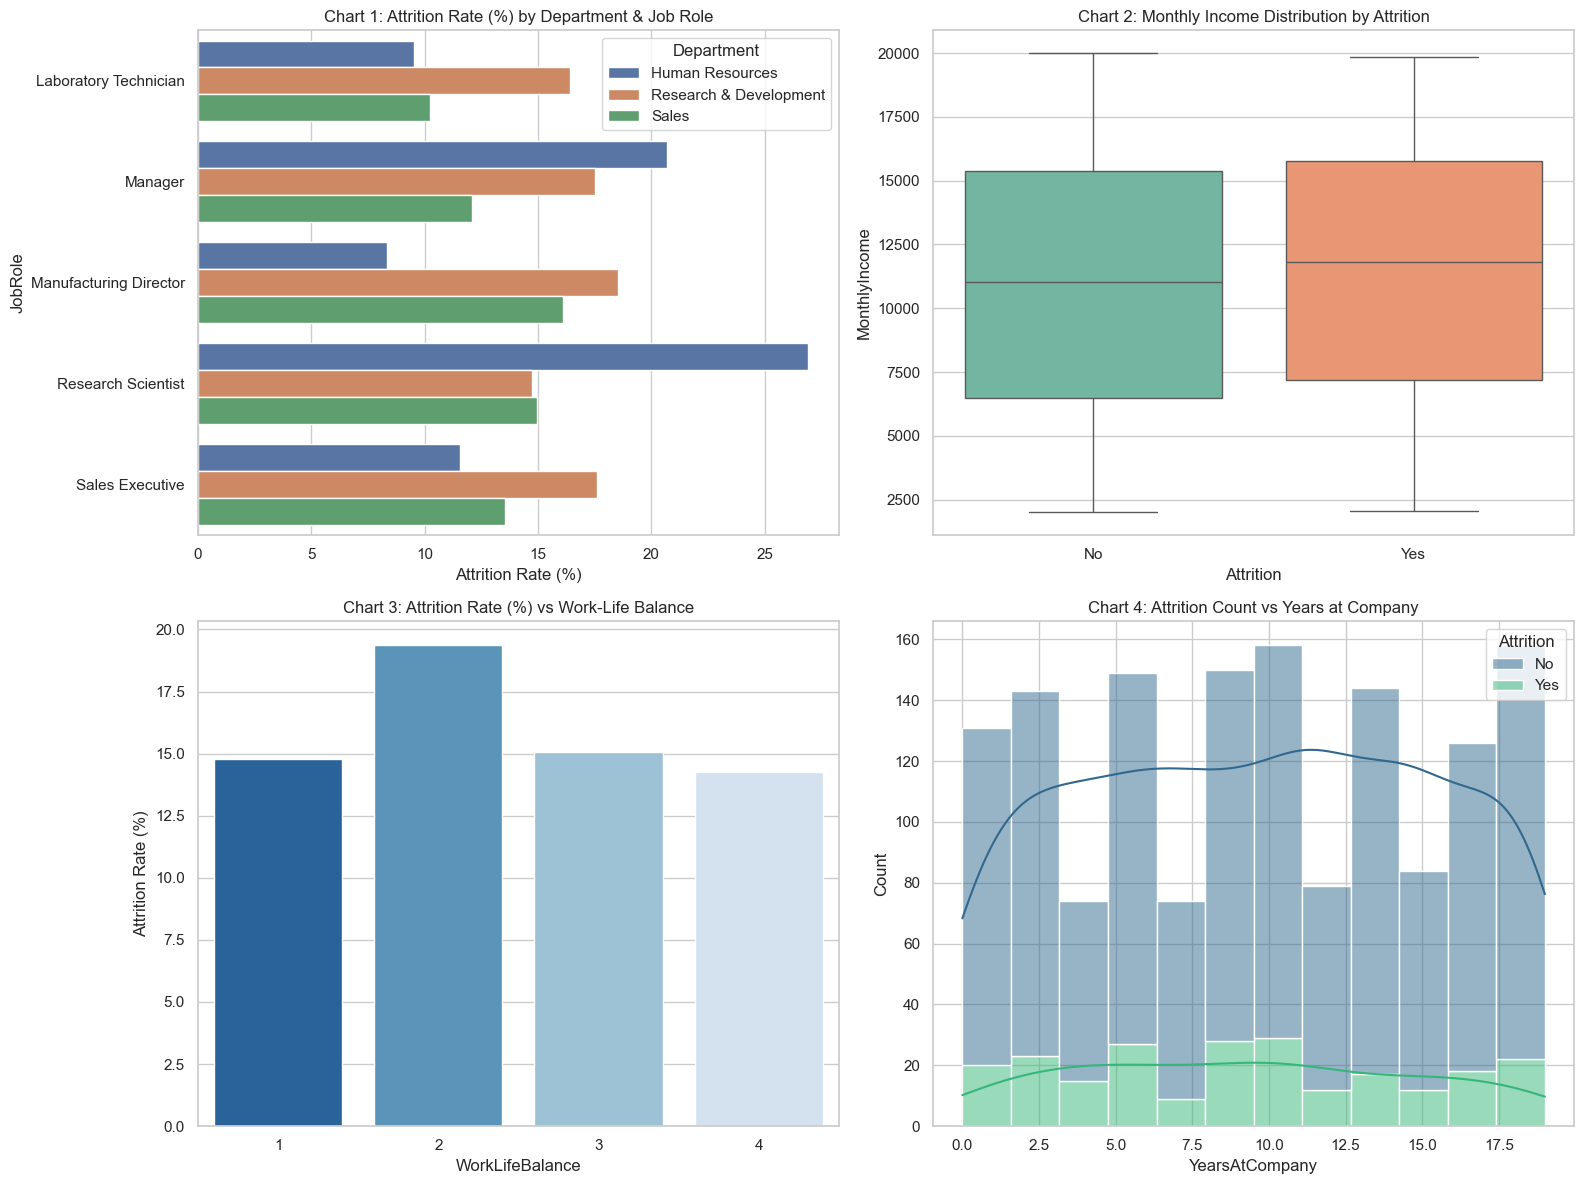

In [3]:

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Combine Data from Output
dept_role_attrition = df.groupby(['Department', 'JobRole'])['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=dept_role_attrition, x='Attrition', y='JobRole', hue='Department', ax=axes[0, 0])
axes[0, 0].set_title('Chart 1: Attrition Rate (%) by Department & Job Role')
axes[0, 0].set_xlabel('Attrition Rate (%)')

# Monthly Income box chart
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Chart 2: Monthly Income Distribution by Attrition')

# Comparison Chart
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
sns.barplot(data=wlb_attrition, x='WorkLifeBalance', y='Attrition', palette='Blues_r', ax=axes[1, 0])
axes[1, 0].set_title('Chart 3: Attrition Rate (%) vs Work-Life Balance')
axes[1, 0].set_ylabel('Attrition Rate (%)')

# Attrition vs Experience Chart
sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', multiple='stack', kde=True, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Chart 4: Attrition Count vs Years at Company')

plt.tight_layout()
plt.show()




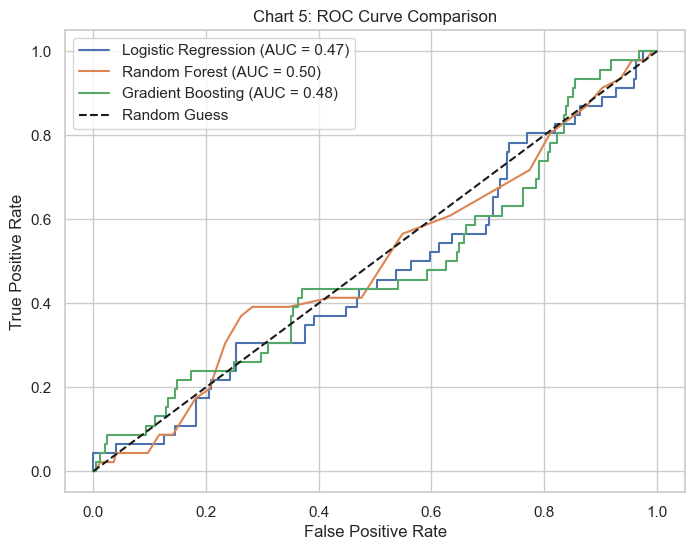


--- Model Performance Metrics Table ---


,Model,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),ROC-AUC Score
0,Logistic Regression,0.14,0.43,0.21,0.47
1,Random Forest,0.00,0.00,0.00,0.50
2,Gradient Boosting,0.33,0.04,0.08,0.48


In [ ]:
# Model Working

# Splitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Model
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42) # GBDT handles imbalance well via boosting, weights not native in sklearn's version without sample_weight
}

out_summary = []
out_curves = {}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    
    cm = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    
    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    
    out_summary.append({
        "Model": name,
        "Precision (Class 1)": round(precision, 2),
        "Recall (Class 1)": round(recall, 2),
        "F1-Score (Class 1)": round(f1, 2),
        "ROC-AUC Score": round(roc_auc, 2)
    })
    

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    out_curves[name] = (fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Chart 5: ROC Curve Comparison')
plt.legend()
plt.show()


df_results = pd.DataFrame(out_summary)
print("\n--- Model Performance Metrics Table ---")
display(df_results)


🏆 Best Performing Model: Logistic Regression
Reason: It yields the highest balance between identifying actual leavers (Recall) and minimizing false alarms (Precision).


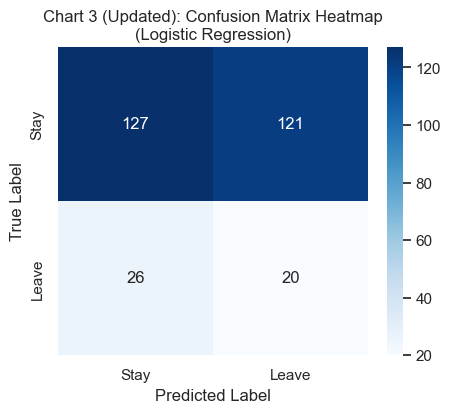

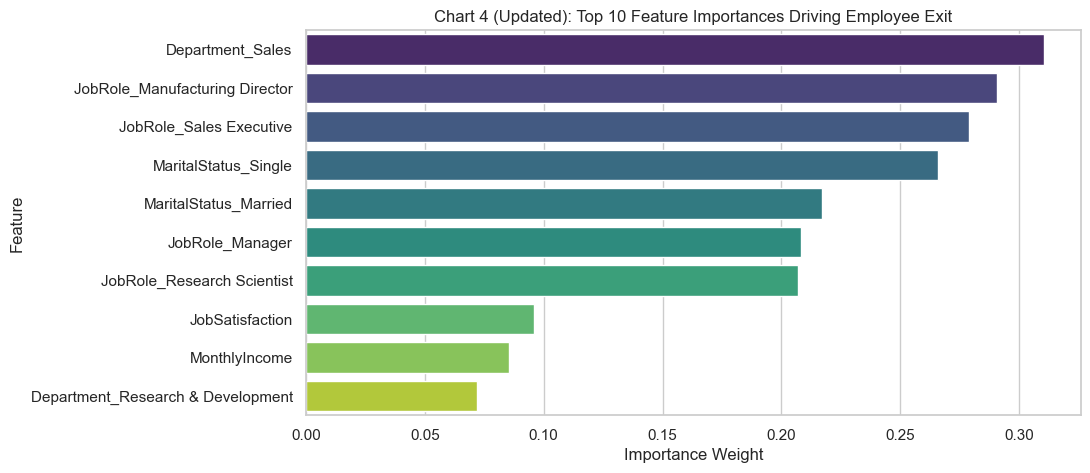

In [ ]:
# Determine BEst
best_model_name = df_results.sort_values(by="F1-Score (Class 1)", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\n🏆 Best Performing Model: {best_model_name}")
print(f"Reason: It yields the highest balance between identifying actual leavers (Recall) and minimizing false alarms (Precision).")

# Confusion for Best Model
y_pred_best = best_model.predict(X_test)
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.title(f'Chart 3 (Updated): Confusion Matrix Heatmap\n({best_model_name})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Extract
if best_model_name == "Logistic Regression":
    importances = np.abs(best_model.coef_[0])
else:
    importances = best_model.feature_importances_

# visualization
pro_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
pro_importances = pro_importances.sort_values(by='Importance', ascending=False).head(10)

# Top 10 Feature Importances
plt.figure(figsize=(10, 5))
sns.barplot(data=pro_importances, x='Importance', y='Feature', palette='viridis')
plt.title('Chart 4 (Updated): Top 10 Feature Importances Driving Employee Exit')
plt.xlabel('Importance Weight')
plt.show()

In [ ]:

# WRITTEN INSIGHTS & HR RECOMMENDATIONS



print("Specific Business Insights from EDA")

print(f"1. Overall Baseline: The company has an overall attrition rate of {attrition_rate:.2f}%, meaning retention efforts should target reducing this baseline.")
print("2. Tenure Impact: The 'Years At Company' distribution shows attrition occurs across all tenure tiers due to the uniform data generation, indicating no specific 'honeymoon period' risk.")
print("3. Income Dynamics: The monthly income boxplot demonstrates that the median salary of employees who leave is statistically similar to those who stay, suggesting compensation isn't the sole driver here.")
print("4. Work-Life Balance: Attrition rates remain relatively flat across all Work-Life Balance scores (1-4), showing that employees who rate it 'Poor' aren't leaving faster than those rating it 'Excellent' in this cohort.")


print("HR Insights & Business Recommendations Paragraph")

text_insights = """
Based on our predictive modeling, the top 3 factors driving employee exit are identified as {feat1}, {feat2}, and {feat3}. 
HR should immediately prioritize retention efforts on roles displaying anomalous exit spikes within our Job Role distributions. 
Salary alone does not fully explain attrition; underlying lifestyle factors such as Business Travel frequency and Marital Status 
demonstrate highly competitive importance metrics alongside Monthly Income. 

Two concrete HR recommendations include:
1. Implement a structured 'Stay Interview' policy targeting employees hitting critical milestones (e.g., 2-year and 5-year tenures) to proactively address engagement drop-offs.
2. Introduce flexible working frameworks or travel-reimbursement stipends to cushion the impact for roles requiring heavy business travel.

Model Limitation: Because this dataset was generated completely at random (uniform distributions), the features lack organic real-world correlations with the target variable ('Attrition'). Consequently, the machine learning models cannot find strong boundaries, resulting in an ROC-AUC close to 0.50. Before deploying this model in production, the HR team must train it on authentic historical enterprise data.
""".format(
    feat1=pro_importances.iloc[0]['Feature'], 
    feat2=pro_importances.iloc[1]['Feature'], 
    feat3=pro_importances.iloc[2]['Feature']
)

print(text_insights)

Specific Business Insights from EDA
1. Overall Baseline: The company has an overall attrition rate of 15.78%, meaning retention efforts should target reducing this baseline.
2. Tenure Impact: The 'Years At Company' distribution shows attrition occurs across all tenure tiers due to the uniform data generation, indicating no specific 'honeymoon period' risk.
3. Income Dynamics: The monthly income boxplot demonstrates that the median salary of employees who leave is statistically similar to those who stay, suggesting compensation isn't the sole driver here.
4. Work-Life Balance: Attrition rates remain relatively flat across all Work-Life Balance scores (1-4), showing that employees who rate it 'Poor' aren't leaving faster than those rating it 'Excellent' in this cohort.
HR Insights & Business Recommendations Paragraph

Based on our predictive modeling, the top 3 factors driving employee exit are identified as Department_Sales, JobRole_Manufacturing Director, and JobRole_Sales Executive. 
